# Decision Trees for Classification and Model Selection

## Table of contents
- Parameters and hyperparameters
- Hyperparameter tuning
- A complete Decision Tree workflow
- Nested cross-validation
- Further reading


## Bibliography

- Bergstra, J. and Bengio, Y., *[Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf)*, *Journal of Machine Learning Research* (2012), 281–305.
- Cawley, G. C. and Talbot, N. L. C., *[On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation](https://www.jmlr.org/papers/volume11/cawley10a/cawley10a.pdf)*, *Journal of Machine Learning Research* 11 (2010), 2079–2107.


# Parameters and hyperparameters


Many machine learning algorithms depend on two different kinds of quantities:

- **Parameters** are learned from the training data.
- **Hyperparameters** are chosen before training starts.

For a **Decision Tree Classifier**:

- the learned **parameters** include the splits selected at the internal nodes;
- the **hyperparameters** include choices such as:
  - the split quality criterion;
  - the maximum tree depth;
  - the minimum number of samples required to split a node.

This distinction is useful because we usually:

1. choose the hyperparameters;
2. train the model;
3. evaluate the result;
4. repeat the process for different hyperparameter values.


In scikit-learn, hyperparameters are passed to the constructor of the estimator class.

```python
sklearn.tree.DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=None
)
```

Important points:

- `DecisionTreeClassifier` is a **class**.
- When we write `DecisionTreeClassifier(...)`, we create an **instance** of that class.
- The values inside the brackets are **arguments**.
- These arguments become the estimator hyperparameters.
- If we do not set a hyperparameter, scikit-learn uses its **default value**.


The separation between parameters and hyperparameters is mainly useful for computation.

A typical workflow has two levels:

- an **outer selection step**, where we compare hyperparameter choices;
- an **inner training step**, where the model learns its parameters from data.

This is why model selection and performance evaluation must be designed carefully.


# Hyperparameter tuning


From the scikit-learn documentation, a hyperparameter search needs four ingredients:

1. an **estimator**;
2. a **cross-validation strategy**;
3. a **scoring rule**;
4. a **search space**.

In this notebook we will use a **Decision Tree Classifier** throughout.
We will compare:

- **grid search**, which tests all combinations in a predefined grid;
- **random search**, which samples a fixed number of combinations.


When only a small number of hyperparameters must be tuned, both approaches are reasonable.

- **Grid search** is systematic.
- **Random search** is often more efficient when we do not know in advance which hyperparameters matter most.

We will use the original datasets from the previous notebook:

- the **digits** dataset for the first experiments;
- the **iris** dataset for the nested cross-validation example.


**Note**

Many other optimisation methods exist, such as Bayesian optimisation.
However, for an introductory lesson, grid search and random search are the clearest starting point because their logic is easy to inspect.


In [4]:



# Standard library import.
# The 'time' function will let us measure how long each search takes.
from time import time

# Plotting libraries.
# seaborn is useful for high-level statistical plots.
# matplotlib is the underlying plotting library used by seaborn.
import seaborn as sns
from matplotlib import pyplot as plt

# NumPy is the main library for numerical arrays in Python.
# In this notebook, NumPy arrays will store feature matrices, label vectors, and numerical results.
import numpy as np

# scikit-learn dataset loader.
# 'load_digits' returns the handwritten digits dataset.
from sklearn.datasets import load_digits

# Model selection utilities.
# - GridSearchCV performs an exhaustive search over a parameter grid.
# - RandomizedSearchCV samples a fixed number of parameter combinations.
# - StratifiedKFold creates cross-validation folds that preserve class proportions.
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

# Classification model used throughout the notebook.
from sklearn.tree import DecisionTreeClassifier


## Load the digits dataset

We load only the first **three classes** of the digits dataset.
This keeps the example small enough for teaching, while still giving us a multi-class problem.

The dataset returns:

- `X`: the input data;
- `y`: the target labels.

Here:

- `X` is a **NumPy array** of shape `(n_samples, n_features)`;
- `y` is a **NumPy array** of shape `(n_samples,)`.


In [5]:

# Load the digits dataset.
# 'return_X_y=True' tells scikit-learn to return the data directly as two arrays:
# - X: features
# - y: labels
# 'n_class=3' keeps only the digit classes 0, 1, and 2.
X, y = load_digits(return_X_y=True, n_class=3)

# Print the number of samples and the number of labels.
# These two numbers are equal because each sample has one label.
len(X), len(y)


(537, 537)

Each row of `X` represents one image.

Important details:

- each image is **8 × 8** pixels;
- therefore each image is flattened into **64 features**;
- each value in `y` is the correct digit class for one image.


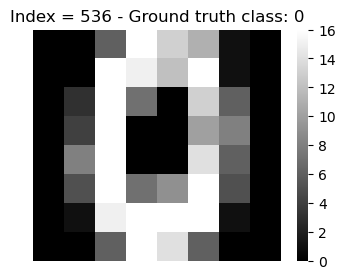

In [6]:

# Choose one sample index to inspect.
# This is simply an integer.
# We set it manually so that the example is reproducible.
check_idx = 536

# Create a figure with a fixed size in inches.
plt.figure(figsize=(4, 3))

# Reshape the selected row from length 64 back to an 8 x 8 image.
# This makes the pixel grid visible again.
sample_image = X[check_idx].reshape(8, 8)

# Draw the image as a heatmap.
# - cmap='gray' uses a grey colour scale
# - yticklabels=False and xticklabels=False hide axis tick labels for clarity
sns.heatmap(sample_image, cmap='gray', yticklabels=False, xticklabels=False)

# Add a title showing the sample index and its true class label.
plt.title(f'Index = {check_idx} - Ground truth class: {y[check_idx]}')

# Display the figure.
plt.show()


## A helper function for search results

The search objects in scikit-learn store many results in a dictionary called `cv_results_`.

A **dictionary** in Python stores pairs of:

- **keys**;
- **values**.

For example, in `cv_results_`:

- the keys are strings such as `'mean_test_score'`;
- the values are arrays or lists containing the corresponding results.

The helper function below prints the best configurations in a readable way.


In [26]:

# Define a utility function.
# A function groups reusable instructions under one name.
def report(results, n_top=10):
    # 'results' is expected to be a dictionary-like object, usually search.cv_results_.
    # 'n_top' is an integer telling the function how many top-ranked configurations to print.

    # Loop over the ranks 1, 2, ..., n_top.
    for i in range(1, n_top + 1):
        # np.flatnonzero returns the indices where the condition is True.
        # Here we find all models whose rank is exactly equal to i.
        candidates = np.flatnonzero(results["rank_test_score"] == i)

        # Loop over all candidate indices with the same rank.
        for candidate in candidates:
            print(f"Model with rank: {i}")
            print(
                f"Mean validation score: "
                f"{results['mean_test_score'][candidate]:.3f} "
                f"(std: {results['std_test_score'][candidate]:.3f})"
            )
            print(f"Parameters: {results['params'][candidate]}")
            print("")


## Define the cross-validation scheme and the classifier

We now define two key objects:

- the cross-validation splitter;
- the classifier.

### Cross-validation splitter
We use `StratifiedKFold` because the task is classification.
It keeps the class proportions approximately constant in every fold.

### Classifier
We create a `DecisionTreeClassifier`.

We set `random_state=42` because some parts of the algorithm can involve randomness.
Fixing the random state makes the example reproducible.

We do **not** set most hyperparameters yet because we want the search procedure to explore them.


In [13]:

# Create a stratified k-fold splitter.
# 'n_splits=10' means that the data will be divided into 10 folds.
# In each round:
# - 9 folds are used for training
# - 1 fold is used for validation
skf = StratifiedKFold(n_splits=10)

# Create the Decision Tree classifier.
# 'random_state=42' fixes the random seed for reproducibility.
# We do not set 'max_depth' or 'min_samples_split' here because
# those are precisely the hyperparameters we want to tune.
clf = DecisionTreeClassifier(random_state=42)


A search needs four ingredients, and we now have all of them:

- an estimator: `clf`;
- a cross-validation scheme: `skf`;
- a score function: the default classification score, which is **accuracy**;
- a search space: we define it next.

We leave the scoring argument unset on purpose.
For `DecisionTreeClassifier`, the default score method is accuracy, which is appropriate for this balanced teaching example.


## Random search

A random search draws a fixed number of hyperparameter combinations from a search space.

We will tune two Decision Tree hyperparameters:

- `max_depth`: the maximum depth of the tree;
- `min_samples_split`: the minimum number of samples required to split an internal node.

We choose small integer ranges so that the behaviour remains easy to read.


In [27]:

# Define the hyperparameter space for random search.
# This is a Python dictionary:
# - each key is the name of a hyperparameter
# - each value is an iterable of candidate values

param_dist = {
    # range(2, 15) generates the integers 2, 3, ..., 14.
    # We start from 2 because a depth of 1 is often too restrictive for this example.
    "max_depth": range(2, 15),

    # range(2, 10, 2) generates 2, 4, 6, 8.
    # This controls how many samples are needed before a node may be split.
    "min_samples_split": range(2, 10, 2),
}

# Create the random search object.
# Important arguments:
# - estimator: the model we want to tune
# - param_distributions: the dictionary defined above
# - n_iter=12: test 12 random configurations
# - cv=skf: use the stratified 10-fold splitter defined earlier
# - random_state=42: make the sampling reproducible
# - n_jobs=-1: use all available CPU cores
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=12,
    cv=skf,
    random_state=42,
    n_jobs=-1,
)

# Measure the running time.
start = time()
random_search.fit(X, y)
random_search_time = time() - start

# Print the elapsed time in seconds.
print(f"Random search completed in {random_search_time:.3f} seconds.")


Random search completed in 7.938 seconds.


In [28]:

# Print the best configurations found by the random search.
report(random_search.cv_results_, n_top=5)


Model with rank: 1
Mean validation score: 0.940 (std: 0.050)
Parameters: {'min_samples_split': 4, 'max_depth': 12}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'min_samples_split': 8, 'max_depth': 13}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'min_samples_split': 8, 'max_depth': 12}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'min_samples_split': 6, 'max_depth': 14}

Model with rank: 5
Mean validation score: 0.938 (std: 0.054)
Parameters: {'min_samples_split': 2, 'max_depth': 10}



The object `random_search.cv_results_` stores the full search output.

Below we extract the tested parameter pairs so that we can mark them on a figure.

The result will be a **list of tuples**.

A **tuple** is an ordered Python collection, similar to a list, but immutable.
Each tuple here has the form:

`(max_depth, min_samples_split)`


In [29]:

# Extract the sampled parameter pairs from the random search results.
# '.data' gives access to the underlying values stored in the masked arrays.
random_params = list(
    zip(
        random_search.cv_results_["param_max_depth"].data,
        random_search.cv_results_["param_min_samples_split"].data,
    )
)

# Show the sampled pairs.
random_params


[(np.int64(6), np.int64(8)),
 (np.int64(12), np.int64(4)),
 (np.int64(13), np.int64(8)),
 (np.int64(5), np.int64(2)),
 (np.int64(12), np.int64(8)),
 (np.int64(3), np.int64(4)),
 (np.int64(6), np.int64(4)),
 (np.int64(14), np.int64(6)),
 (np.int64(2), np.int64(8)),
 (np.int64(10), np.int64(2)),
 (np.int64(5), np.int64(4)),
 (np.int64(4), np.int64(2))]

## Grid search

A grid search evaluates **all** combinations in a predefined grid.

Because our grid is small, an exhaustive search is feasible.
This makes the comparison with random search very clear.


In [17]:

# Define the parameter grid for the exhaustive search.
# We reuse exactly the same candidate values as before so that the comparison is fair.
param_grid = {
    "max_depth": range(2, 15),
    "min_samples_split": range(2, 10, 2),
}

# Create the grid search object.
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=skf,
    n_jobs=-1,
)

# Measure the running time.
start = time()
grid_search.fit(X, y)
grid_search_time = time() - start

# Print the elapsed time.
print(f"Grid search completed in {grid_search_time:.3f} seconds.")


Grid search completed in 0.652 seconds.


In [18]:

# Print the best configurations found by the grid search.
report(grid_search.cv_results_, n_top=5)


Model with rank: 1
Mean validation score: 0.940 (std: 0.050)
Parameters: {'max_depth': 10, 'min_samples_split': 4}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'max_depth': 10, 'min_samples_split': 6}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'max_depth': 10, 'min_samples_split': 8}

Model with rank: 1
Mean validation score: 0.940 (std: 0.050)
Parameters: {'max_depth': 11, 'min_samples_split': 4}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'max_depth': 11, 'min_samples_split': 6}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'max_depth': 11, 'min_samples_split': 8}

Model with rank: 1
Mean validation score: 0.940 (std: 0.050)
Parameters: {'max_depth': 12, 'min_samples_split': 4}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters: {'max_depth': 12, 'min_samples_split': 6}

Model with rank: 1
Mean validation score: 0.940 (std: 0.053)
Parameters:

The complete grid search results are also stored in `grid_search.cv_results_`.

This object is useful, but it is not very easy to read directly because it contains many arrays.
We will therefore convert it into a pandas DataFrame and then into a pivot table.


In [19]:

# Import pandas only when we need tabular data manipulation.
import pandas as pd

# Convert the grid-search results dictionary into a DataFrame.
results_df = pd.DataFrame(grid_search.cv_results_)

# Build a pivot table.
# Rows correspond to 'max_depth'.
# Columns correspond to 'min_samples_split'.
# Values are the mean validation accuracies.
pvt = pd.pivot_table(
    results_df,
    values="mean_test_score",
    index="param_max_depth",
    columns="param_min_samples_split",
)

# Display the pivot table.
pvt


param_min_samples_split,2,4,6,8
param_max_depth,,,,
2,0.906883,0.906883,0.906883,0.906883
3,0.925611,0.925611,0.925611,0.925611
4,0.923515,0.921628,0.921628,0.923515
5,0.932844,0.932844,0.929140,0.929140
6,0.930957,0.932844,0.929140,0.929140
7,0.930957,0.932844,0.932844,0.932844
8,0.930957,0.932844,0.932844,0.932844
9,0.936513,0.938400,0.938400,0.938400
10,0.938365,0.940252,0.940252,0.940252


The heatmap below shows the average validation accuracy for every grid-search combination.

We also add red crosses for the configurations sampled by random search.

This figure helps us compare:

- the full coverage of grid search;
- the sampled coverage of random search.


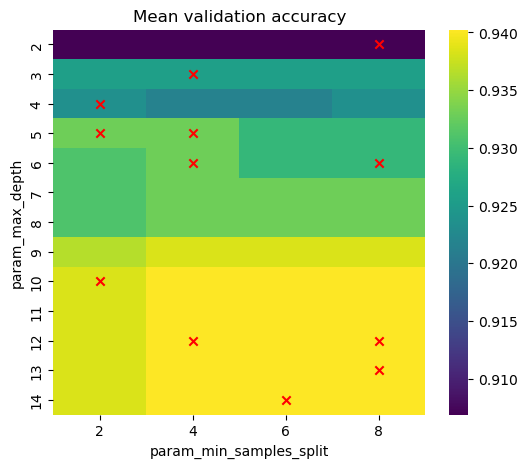

In [20]:

# Create the figure and axes.
f, ax = plt.subplots(figsize=(6, 5))

# Draw the heatmap from the pivot table.
sns.heatmap(pvt, cmap="viridis", ax=ax)

# Add a title.
plt.title("Mean validation accuracy")

# Add one red cross for each parameter pair tested by random search.
# The coordinate adjustment is only needed because heatmap cells are centred on grid positions.
for max_depth_value, min_samples_split_value in random_params:
    ax.scatter(
        min_samples_split_value / 2 - 0.5,
        max_depth_value - 1.5,
        color="r",
        marker="x",
    )

# Explain the red crosses.
# We use a comment rather than extra code because the visual meaning is already clear.
# Red crosses indicate the configurations tested by random search.

plt.show()


So, which approach is better?

The answer depends on the problem and on the search space.

A common conclusion, supported by Bergstra and Bengio, is the following:

- if we already know which hyperparameters are most influential, a well-designed grid can work well;
- if we do not know that in advance, random search often explores the important directions more efficiently.

In other words, random search may spend its budget more wisely in high-dimensional spaces.


Consider the following conceptual example with a budget of only nine trials in a two-dimensional hyperparameter space.

<div>
<img src="https://miro.medium.com/proxy/1*ZTlQm_WRcrNqL-nLnx6GJA.png" width="700"/>
</div>

Key idea:

- **grid search** covers the two-dimensional space evenly;
- **random search** covers the individual dimensions more flexibly.

This is one reason why random search is often a strong baseline.


**Practical note**

When you use an estimator, always read its documentation carefully.
For a Decision Tree, this is especially important because even a small change in a hyperparameter can affect:

- tree size;
- interpretability;
- risk of overfitting.


# A complete Decision Tree workflow


In this part we keep the focus on **Decision Trees**.

Why do we **not** build a preprocessing pipeline here?

- Decision Trees do **not** require feature standardisation.
- We also avoid PCA in this introductory lesson because it would make the workflow less transparent.
- Our goal is to understand the behaviour of the tree itself before adding extra components.

So, instead of a pipeline, we build a complete and explicit Decision Tree tuning workflow.


We now tune a slightly richer set of Decision Tree hyperparameters on the same digits dataset.

This shows how a real search object is usually defined in practice.


In [21]:

# Define a larger but still manageable parameter grid for the Decision Tree.
# Each dictionary key is a hyperparameter name.
# Each dictionary value is a list of candidate settings.

complete_param_grid = {
    # Quality measure used to evaluate a split.
    # We test two common criteria.
    "criterion": ["gini", "entropy"],

    # Maximum depth of the tree.
    # 'None' means no explicit depth limit.
    "max_depth": [None, 3, 5, 7, 9, 12],

    # Minimum number of samples required to split an internal node.
    "min_samples_split": [2, 4, 6, 8],

    # Minimum number of samples required to remain in a leaf node.
    "min_samples_leaf": [1, 2, 4],
}

# Create a new search object.
# We use the same classifier family and the same cross-validation strategy.
complete_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=complete_param_grid,
    cv=skf,
    n_jobs=-1,
)

# Fit the search object on the digits data.
complete_search.fit(X, y)

# Print the best score and the best parameter combination.
print("Best mean validation accuracy:", complete_search.best_score_)
print("Best hyperparameters:", complete_search.best_params_)


Best mean validation accuracy: 0.9460517120894479
Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [22]:

# Convert the complete search results into a DataFrame for inspection.
complete_results_df = pd.DataFrame(complete_search.cv_results_)

# Show a few useful columns only.
# This keeps the output readable for students.
complete_results_df[
    [
        "mean_test_score",
        "std_test_score",
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "rank_test_score",
    ]
].sort_values(by="rank_test_score").head(10)


,mean_test_score,std_test_score,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,rank_test_score
76,0.946052,0.050692,entropy,None,2,2,1
124,0.946052,0.050692,entropy,9,2,2,1
77,0.946052,0.050692,entropy,None,4,2,1
113,0.946052,0.050692,entropy,7,4,2,1
112,0.946052,0.050692,entropy,7,2,2,1
136,0.946052,0.050692,entropy,12,2,2,1
137,0.946052,0.050692,entropy,12,4,2,1
125,0.946052,0.050692,entropy,9,4,2,1
126,0.944165,0.051797,entropy,9,6,2,9
114,0.944165,0.051797,entropy,7,6,2,9


This table shows the top-ranked Decision Tree settings.

Notice that we still leave some hyperparameters at their default values.

For example, we do **not** tune:

- `splitter`;
- `max_features`;
- `class_weight`.

We leave them unset here for teaching reasons:

- too many hyperparameters at once would hide the main ideas;
- the current dataset is simple enough for a focused demonstration;
- the first goal is to understand the effect of depth and minimum sample constraints.


# Nested cross-validation


Two core tasks in machine learning are:

- **model selection**;
- **performance evaluation**.

Hyperparameter tuning belongs to model selection.
However, the score obtained during tuning is **not** automatically an unbiased estimate of generalisation performance.


## Why is a single level of cross-validation not enough?

If we use the same validation folds both:

- to choose the best hyperparameters;
- and to report final performance,

then the estimate can be optimistic.

This happens because the model selection process has already adapted itself to those validation folds.


<font color=green>**If a separate test set is available**</font>

A clean solution is:

1. keep the test set untouched;
2. tune hyperparameters only on the training data;
3. evaluate the final chosen model on the test set once.

<div>
<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width="800"/>
</div>


<font color=green>**If a separate test set is not available**</font>

We can use **nested cross-validation**.

- the **inner loop** selects the hyperparameters;
- the **outer loop** estimates generalisation performance.

This keeps selection and final evaluation separate.


<div>
<img src="https://i.stack.imgur.com/vh1sZ.png" width="800"/>
</div>


Let's consider the **iris** dataset and a **Decision Tree** classifier.


In [23]:

# Imports for the nested cross-validation example.
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score

# Number of repeated trials.
# We repeat the experiment many times because the result depends on the random splits.
NUM_TRIALS = 100

# Load the iris dataset.
# X_iris is the feature matrix.
# y_iris is the target vector.
X_iris, y_iris = load_iris(return_X_y=True)


We now compare two procedures.

## Non-nested procedure
- tune hyperparameters with cross-validation;
- report the best cross-validation score directly.

## Nested procedure
- tune hyperparameters in the inner loop;
- evaluate the tuned model in an outer loop.

The second procedure is more reliable as a performance estimate.


In [ ]:

# Create arrays to store the final scores from each trial.
# np.zeros(NUM_TRIALS) creates a NumPy array filled with zeros.
non_nested_scores = np.zeros(NUM_TRIALS)
nested_scores = np.zeros(NUM_TRIALS)

# Loop over the repeated trials.
for i in range(NUM_TRIALS):
    # Define the inner and outer cross-validation strategies.
    # shuffle=True randomises the assignment of samples to folds.
    # random_state=i changes the split from one trial to the next in a reproducible way.
    inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

    # Define the parameter grid for the Decision Tree.
    # The values are intentionally simple so that the example stays easy to follow.
    dt_param_grid = {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 2, 3, 4, 5, 6],
        "min_samples_split": [2, 4, 6, 8],
    }

    # Create the grid-search object used inside both procedures.
    dt_search = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=dt_param_grid,
        cv=inner_cv,
        n_jobs=-1,
    )

    # >>>>>>>>>>>>Non-nested score:
    # Fit the grid-search object on the entire dataset.
    dt_search.fit(X_iris, y_iris)
    # ***For each combination of hyperparameters***, GridSearchCV performs
    # a 4-fold cross-validation and computes the average validation score.

    non_nested_scores[i] = dt_search.best_score_
    # The attribute best_score_ is the highest average score 
    # computed considering all the cross-validation folds at iteraion i.
    # This value is stored as the performance estimate for the hyperparameter combination i.

    # Thus, I have a score for each point of the hyperparameter grid, and this score is 
    # the average performance across the validation folds. 

    # Note: this estimate may be optimistic, because the same data are used
    # both to select the model and to evaluate it.
    # In the non-nested procedure, the model selection and evaluation are not separated.
    # We use cross-validation to choose the best model, and then we reuse 
    # the same validation score as performance estimate.

    # --------------------------------------------------------------------------------------

    # >>>>>>>>>>>>Nested score:
    # cross_val_score performs the outer cross-validation.
    # OUTER LOOP: splits the data into outer training folds and an outer validation fold (aka outer test fold).
    #             Then, ****for each hyperparameter combination****, dt_search considers the training folds, trains the model, 
    #             and evaluates it on the validation fold. It repeats this process for all inner validation folds.
    #             It finally averages the validation scores across the inner validation folds to get a single score for that hyperparameter combination.
    #             The second inner loop considers the second hyperparameter combination, and gets another validation score, 
    #             and so on for all the hyperparameter combinations.
    #             The final result of one iteration of the outer loop is the hyperparameter combination with the highest average validation score.
    #             The outer loop then evaluates the selected hyperparameter combination on the outer validation fold, and stores the score.
    #             This process is repeated for all outer folds, and the final nested score is the average of the scores obtained on the outer validation folds.

    # The inner search is the same as in the non-nested procedure, but it is performed
    # separately on each outer training fold. 
    nested_score = cross_val_score(dt_search, X=X_iris, y=y_iris, cv=outer_cv, n_jobs=-1)

    # Store the average outer score for this trial.
    nested_scores[i] = nested_score.mean()

# Compute the difference between the two procedures.
score_difference = non_nested_scores - nested_scores

# Print summary statistics.
print("Average non-nested score:", non_nested_scores.mean())
print("Average nested score:", nested_scores.mean())
print("Average difference:", score_difference.mean())


Average non-nested score: 0.9516251778093884
Average nested score: 0.9397403982930298
Average difference: 0.011884779516358468


The plot below compares the two estimates over many trials.

A small gap does not mean that nested cross-validation is unnecessary in principle.
It means only that, for this dataset and this model family, the optimism may be limited.


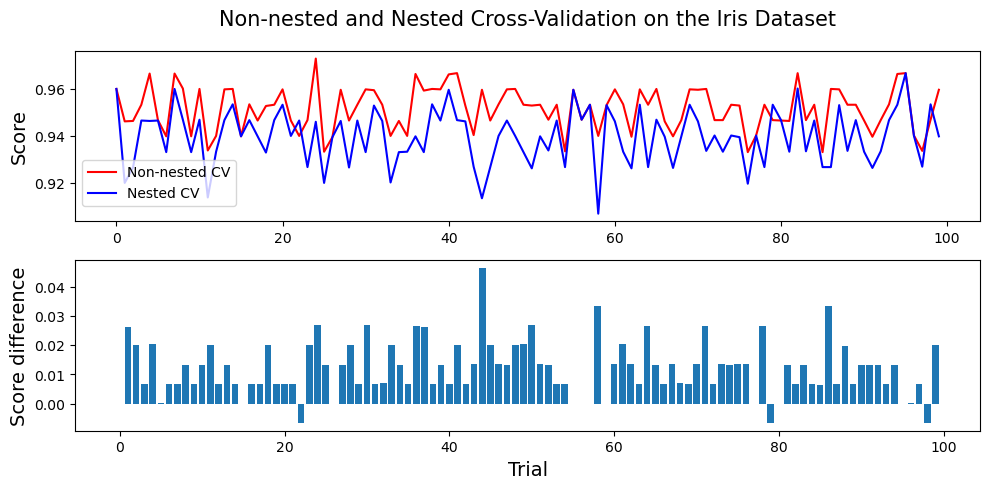

In [25]:

# Plot the score obtained in each trial.
plt.figure(figsize=(10, 5))

# First panel: direct comparison across trials.
plt.subplot(211)
(non_nested_scores_line,) = plt.plot(non_nested_scores, color="r")
(nested_line,) = plt.plot(nested_scores, color="b")
plt.ylabel("Score", fontsize=14)
plt.legend(
    [non_nested_scores_line, nested_line],
    ["Non-nested CV", "Nested CV"],
    bbox_to_anchor=(0, 0.4, 0.5, 0),
)
plt.title(
    "Non-nested and Nested Cross-Validation on the Iris Dataset",
    x=0.5,
    y=1.1,
    fontsize=15,
)

# Second panel: difference between the two procedures.
plt.subplot(212)
difference_plot = plt.bar(range(NUM_TRIALS), score_difference)
plt.ylabel("Score difference", fontsize=14)
plt.xlabel("Trial", fontsize=14)

# Keep a clean layout.
plt.tight_layout()
plt.show()


## Final considerations

- Nested cross-validation is computationally more expensive than a single cross-validation loop.
- Its main benefit is a more reliable estimate of generalisation performance.
- In small educational examples, the difference may be modest.
- In serious model comparison studies, the distinction is often important.

A practical lesson is this:

- use ordinary cross-validation for tuning;
- use a clean final test set, or nested cross-validation, when you need an unbiased performance estimate.


# Further reading

- [Decision Trees in scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
- [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html#tuning-the-hyper-parameters-of-an-estimator)
- [Nested versus non-nested cross-validation example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)
- [Searching for optimal parameters with successive halving](https://scikit-learn.org/stable/modules/grid_search.html#searching-for-optimal-parameters-with-successive-halving)
